In [1]:
# Set up the file path, import packages, and define device
# Set up the file path
import sys
import os
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..'))
sys.path.append(parent_dir)
print('Parent directory set to:', parent_dir)

# Specify the target directory
target_directory = '/local0/home/mfilo/git/CRN-GenerativeAI/apps_results_MAK_REINFORCE/multistability_2species_6rxns'

# Import general packages
import torch
import numpy as np
from itertools import product, combinations_with_replacement
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from matplotlib.lines import Line2D

# Import CRN packages
from RL4CRN.iocrns.iocrn import IOCRN
from RL4CRN.utils.ic import IC

# Import Reward packages
from RL4CRN.rewards.deterministic import dynamic_tracking_error

# Import Visualization packages
from RL4CRN.utils.visualizations import plot_reactant_product_heatmap, plot_reactant_product_scatter, topology_graph
from RL4CRN.utils.visualizations import visualize_crn_diversity

# Device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')
N_CPUs = os.cpu_count() if os.cpu_count() is not None else 1
print(f'Number of CPUs available: {os.cpu_count()}') 

Parent directory set to: /local0/home/mfilo/git/CRN-GenerativeAI
Using device: cuda
Number of CPUs available: 128


In [2]:
# Flag to save generated figures
save_figures_flag = True

# Flag to resimulate the IOCRN dynamics of the halls of fame
resimulate_flag = False 

# Flag to load generated IOCRNs from trained models
generated_flag = True

# Flag for filtering out repeated IOCRN topologies
filter_flag = True
num_reactions_template = 2

# Parallel simulation flag
parallel_flag = True

# Set number of inputs and species labels
p = 1                                                   # Number of inputs
species_labels = ['X_1', 'X_2']                         # Species labels
mak_order = 2                                           # Maximum order of the mass-action reactions

# Time horizon for the simulation
t_f = 100                                               # Final time for the simulation
N_t = 1000                                              # Number of time steps in the simulation
time_horizon = np.linspace(0, t_f, N_t, dtype=np.float32)

# Construct the IOCRN inputs
u_list = [np.array([1.0])]

# Construct the IOCRN initial conditions
epsilon = 1e-3
ic_values_diagonal_1 = [[x/10, x/10 - 0.3] for x in range(3, 13)]
ic_values_diagonal_2 = [[x/10, x/10 + 0.3] for x in range(0, 10)]
ic_values_cluster_1 = [ [.9, epsilon], [1, epsilon], [1.1, epsilon], 
                        [.9, .1], [1, .1], [1.1, .1]]
ic_values_cluster_2 = [ [epsilon, .9], [epsilon, 1], [epsilon, 1.1], 
                        [.1, .9], [.1, 1], [.1, 1.1]]
ic_values = ic_values_diagonal_1 + ic_values_diagonal_2 + ic_values_cluster_1 + ic_values_cluster_2
ic = IC(names=species_labels, values=ic_values)

# Construct the desired fixed points
r_list = [np.array([1, 0])] * len(ic_values_diagonal_1) + \
         [np.array([0, 1])] * len(ic_values_diagonal_2) + \
         [np.array([1, 0])] * len(ic_values_cluster_1) + \
         [np.array([0, 1])] * len(ic_values_cluster_2)

# Construct the weights for the performance metric
w = np.ones(N_t)
w[(len(w)//5)*4:] = w[(len(w)//5)*4:]*2
w[:(len(w)//5)] = w[:(len(w)//5)]*0.25
w = w[np.newaxis, :]

# Construct the compute reward routine
def compute_reward(state):
    x0_list = ic.get_ic(state)
    return dynamic_tracking_error(state, u_list, x0_list, time_horizon, r_list, w, norm=1, relative=False, LARGE_NUMBER=1e4)

# Define path for the directories: hall of fame and models
base_path_hof = os.path.abspath(os.path.join(target_directory, 'hof'))
base_path_models = os.path.abspath(os.path.join(target_directory, 'models'))
print(f"Current working directory: {os.getcwd()}")
print(f"Base path for halls of fame: {base_path_hof}")
print(f"Base path for models: {base_path_models}")

Current working directory: /local0/home/mfilo/git/CRN-GenerativeAI/apps_results_MAK_REINFORCE/multistability_2species_6rxns/plots
Base path for halls of fame: /local0/home/mfilo/git/CRN-GenerativeAI/apps_results_MAK_REINFORCE/multistability_2species_6rxns/hof
Base path for models: /local0/home/mfilo/git/CRN-GenerativeAI/apps_results_MAK_REINFORCE/multistability_2species_6rxns/models


In [3]:
# Collect IOCRNs from halls of fame and those generated by trained models
# Get list of hall of fame files
hof_files = [f for f in os.listdir(base_path_hof) if f.startswith('hall_of_fame_') and f.endswith('.pth')]
print(f"Found {len(hof_files)} hall of fame files:")
for file in hof_files:
    print(f"- {file}")
print("-" * 40)

# Get list of generated files
generated_files = [f for f in os.listdir(base_path_models) if f.startswith('generated') and f.endswith('.pth')]
print(f"Found {len(generated_files)} generated files:")
for file in generated_files:
    print(f"- {file}")
print("-" * 40)

# Load the list of IOCRNs from each hall of fame file
hof_data = {}
for file in hof_files:
    file_path = os.path.join(base_path_hof, file)
    hof_data[file] = torch.load(file_path, weights_only=False)
    print(f"Loaded {file} with {len(hof_data[file])} entries.")

# Collect all IOCRNs from the halls of fame into a single list
hof_iocrns = []
for file, iocrn_list in hof_data.items():
    hof_iocrns.extend(iocrn_list)
print("-" * 40)
print(f"Total IOCRNs collected from all halls of fame: {len(hof_iocrns)}")
print("-" * 40)

if generated_flag:
    # Load the list of generated IOCRNs
    generated_data = {}
    for file in generated_files:
        file_path = os.path.join(base_path_models, file)
        generated_data[file] = torch.load(file_path, weights_only=False)
        print(f"Loaded {file} with {len(generated_data[file])} entries.")

    # Collect all IOCRNs from the generated files into a single list
    generated_iocrns = []
    for file, iocrn_list in generated_data.items():
        generated_iocrns.extend(iocrn_list)
    print("-" * 40)
    print(f"IOCRNs collected from all generated files: {len(generated_iocrns)}")

# Collect all IOCRNs into a single list
all_iocrns = hof_iocrns.copy()
if generated_flag:
    all_iocrns.extend(generated_iocrns)
print("-" * 40)
print(f"Total IOCRNs: {len(all_iocrns)}")

Found 3 hall of fame files:
- hall_of_fame_2025-12-22 15:08:28.pth
- hall_of_fame_2025-12-23 20:46:46.pth
- hall_of_fame_2025-12-08 07:44:18.pth
----------------------------------------
Found 3 generated files:
- generated_2025-12-23 20:46:46.pth
- generated_2025-12-08 07:44:18.pth
- generated_2025-12-22 15:08:28.pth
----------------------------------------
Loaded hall_of_fame_2025-12-22 15:08:28.pth with 30 entries.
Loaded hall_of_fame_2025-12-23 20:46:46.pth with 30 entries.
Loaded hall_of_fame_2025-12-08 07:44:18.pth with 10 entries.
----------------------------------------
Total IOCRNs collected from all halls of fame: 70
----------------------------------------
Loaded generated_2025-12-23 20:46:46.pth with 1280 entries.
Loaded generated_2025-12-08 07:44:18.pth with 1280 entries.
Loaded generated_2025-12-22 15:08:28.pth with 1280 entries.
----------------------------------------
IOCRNs collected from all generated files: 3840
----------------------------------------
Total IOCRNs: 3

In [4]:
# Resimulate the dynamics of each IOCRN if the flag is set
if resimulate_flag:
    print("Resimulating IOCRN dynamics...")

    # Reset all IOCRNs
    for iocrn in all_iocrns:
        iocrn.reset()

    # Simulate each IOCRN
    if parallel_flag:
        results = Parallel(n_jobs=N_CPUs)(delayed(compute_reward)(iocrn) for iocrn in all_iocrns) 
    else:
        results = []
        for iocrn in all_iocrns:
            results.append(compute_reward(iocrn))

    # Unzip the results
    rewards_list, last_task_info_list = zip(*results)
    rewards_list = list(rewards_list)
    last_task_info_list = list(last_task_info_list)

    # Update the last task info in each IOCRN since running in parallel does not modify the IOCRNs themselves
    for i, iocrn in enumerate(all_iocrns):
        iocrn.last_task_info = last_task_info_list[i]            

Filtering topologically unique IOCRNs...
Number of topologically unique IOCRNs: 3149 out of 3910 total IOCRNs.


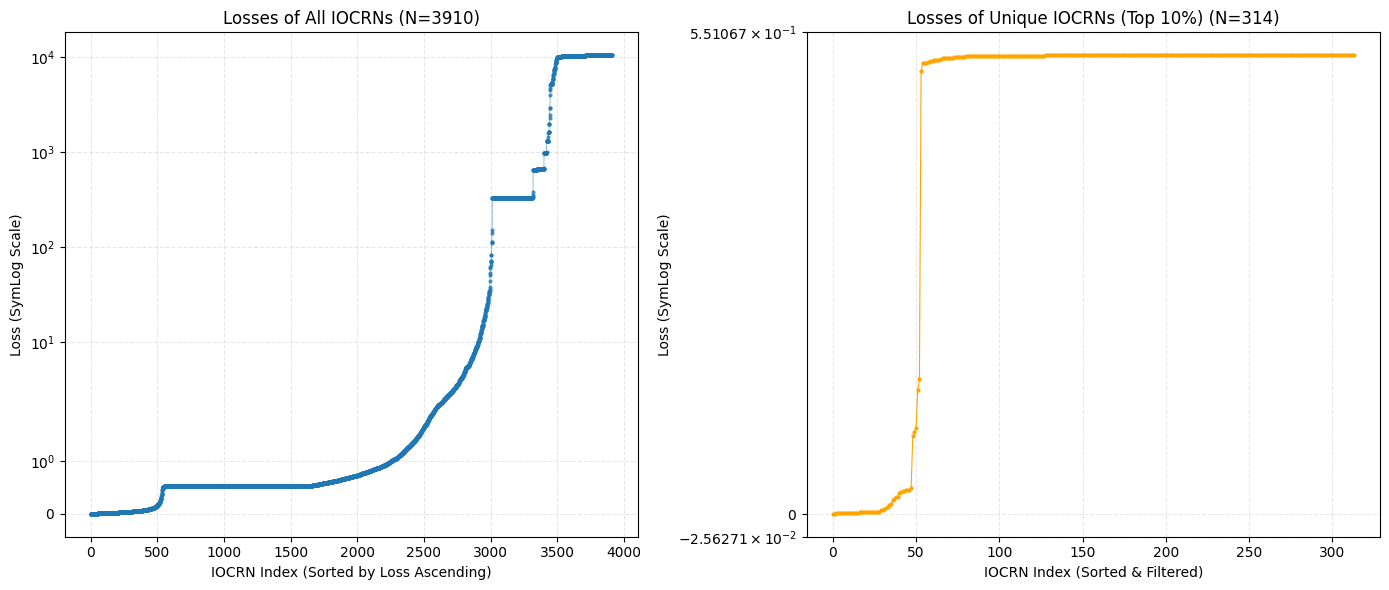

In [5]:
def plot_unique_rewards(all_iocrns, filter_flag=True, top_percentile=100, figsize=(14, 6)):
    """
    Sorts IOCRNs by reward (loss), optionally filters for topological uniqueness, 
    and plots the reward distribution.

    Args:
        all_iocrns (list): List of IOCRN objects. Each must have .last_task_info['reward'] 
                           and .is_topologically_equal().
        filter_flag (bool): If True, removes topologically duplicate CRNs, keeping the 
                            best-performing version of each topology.
        top_percentile (float): If < 100, restricts the "Unique" plot to the top X% 
                                of topologies. (e.g., 10 = top 10%).
        figsize (tuple): Figure size for the plot.
    """
    
    # 1. Sort all IOCRNs by reward/loss.
    # User Request: "Plotting a loss" -> "Lower values on the left".
    # This implies Ascending Order (Smallest/Best -> Largest/Worst).
    all_iocrns_sorted = sorted(all_iocrns, key=lambda iocrn: iocrn.last_task_info['reward'], reverse=False)

    # 2. Filter topologically unique IOCRNs
    if filter_flag:
        print("Filtering topologically unique IOCRNs...")
        all_iocrns_sorted_filtered = []
        
        if all_iocrns_sorted:
            # The list is sorted [Best, ..., Worst].
            # To keep the BEST version of each topology, we iterate FORWARD.
            # The first time we see a topology, it is the best one (lowest index in sorted list).
            unique_indices = []
            seen_topologies = []
            
            for i in range(len(all_iocrns_sorted)):
                candidate = all_iocrns_sorted[i]
                is_new = True
                for seen in seen_topologies:
                    if candidate.is_topologically_equal(seen):
                        is_new = False
                        break
                
                if is_new:
                    seen_topologies.append(candidate)
                    unique_indices.append(i)
            
            all_iocrns_sorted_filtered = [all_iocrns_sorted[i] for i in unique_indices]
            
        print(f"Number of topologically unique IOCRNs: {len(all_iocrns_sorted_filtered)} out of {len(all_iocrns_sorted)} total IOCRNs.")

    else:
        all_iocrns_sorted_filtered = all_iocrns_sorted

    # 3. Apply Percentile Cutoff (to the Filtered list)
    if top_percentile < 100:
        n_total = len(all_iocrns_sorted_filtered)
        n_keep = max(1, int(n_total * (top_percentile / 100.0)))
        
        # Keep the FIRST n_keep items (Lowest Loss / Best Performance)
        all_iocrns_sorted_filtered = all_iocrns_sorted_filtered[:n_keep]
        title_suffix = f" (Top {top_percentile}%)"
    else:
        title_suffix = ""

    # 4. Extract Rewards
    rewards_sorted = [iocrn.last_task_info['reward'] for iocrn in all_iocrns_sorted]
    rewards_sorted_filtered = [iocrn.last_task_info['reward'] for iocrn in all_iocrns_sorted_filtered]

    # 5. Plotting
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)

    # Left Plot: All IOCRNs
    ax1.plot(rewards_sorted, marker='o', markersize=2, linestyle='-', linewidth=0.5, alpha=0.7)
    ax1.set_yscale('symlog') # symlog handles negative rewards better than log
    ax1.set_xlabel('IOCRN Index (Sorted by Loss Ascending)')
    ax1.set_ylabel('Loss (SymLog Scale)')
    ax1.set_title(f'Losses of All IOCRNs (N={len(rewards_sorted)})')
    ax1.grid(True, which="both", ls="--", alpha=0.3)

    # Right Plot: Unique / Top Percentile
    ax2.plot(rewards_sorted_filtered, marker='o', color='orange', markersize=2, linestyle='-', linewidth=0.8)
    ax2.set_yscale('symlog') # Kept as symlog
    ax2.set_xlabel('IOCRN Index (Sorted & Filtered)')
    ax2.set_ylabel('Loss (SymLog Scale)')
    ax2.set_title(f'Losses of Unique IOCRNs{title_suffix} (N={len(rewards_sorted_filtered)})')
    ax2.grid(True, which="both", ls="--", alpha=0.3)
    
    # Ensure tick labels are visible on Y axis
    ax2.yaxis.set_minor_formatter(plt.ScalarFormatter())

    plt.tight_layout()
    plt.show()

    return all_iocrns_sorted, all_iocrns_sorted_filtered

# Plot the rewards with filtering and top percentile options
all_iocrns_sorted, all_iocrns_sorted_filtered = plot_unique_rewards(all_iocrns, filter_flag=filter_flag, top_percentile=10, figsize=(14, 6))

In [6]:
# Select the top IOCRNs and top topologically unique IOCRNs to visualize
n_unfiltered = 100
n_filtered = 40

sorting...
done ... 
Unfiltered: IOCRN # 0 has a reward of 0.0005862443980116228
Unfiltered: IOCRN # 100 has a reward of 0.01302601562601643
Filtered: IOCRN # 0 has a reward of 0.0005862443980116228
Filtered: IOCRN # 40 has a reward of 0.019977691739897115


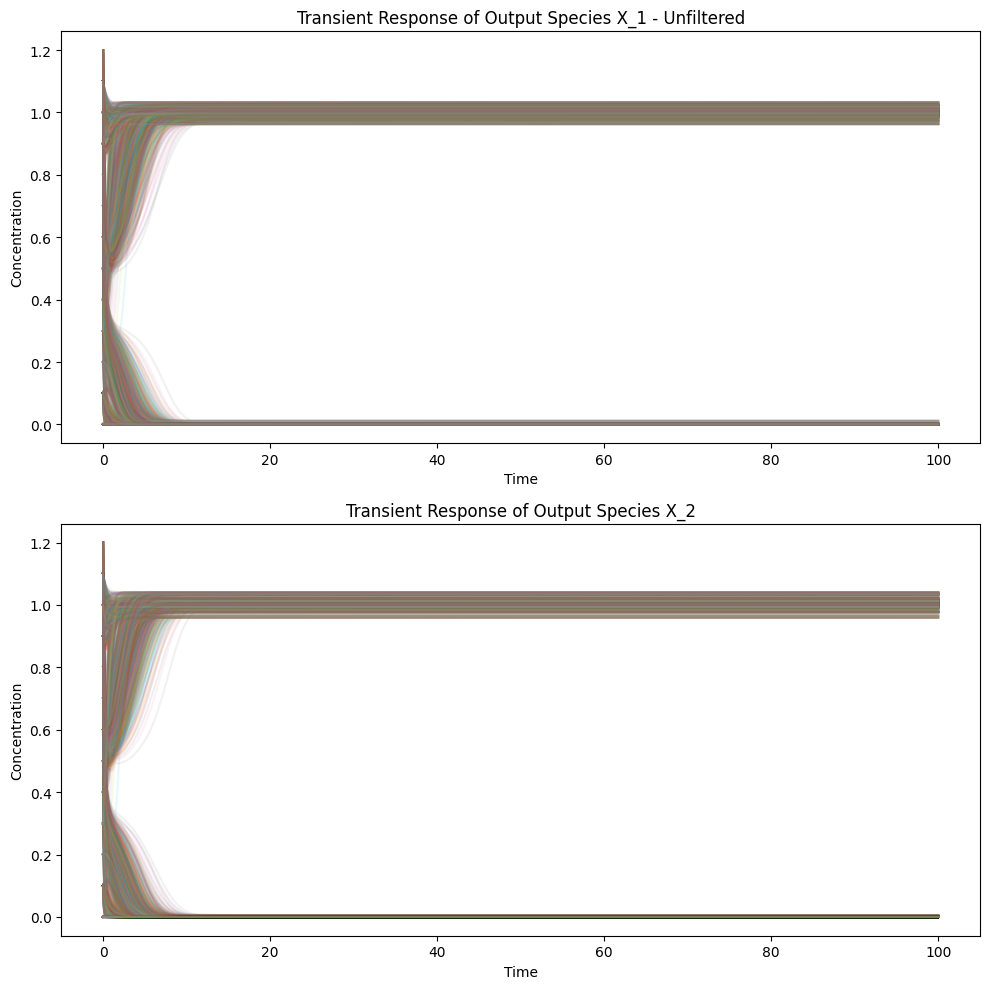

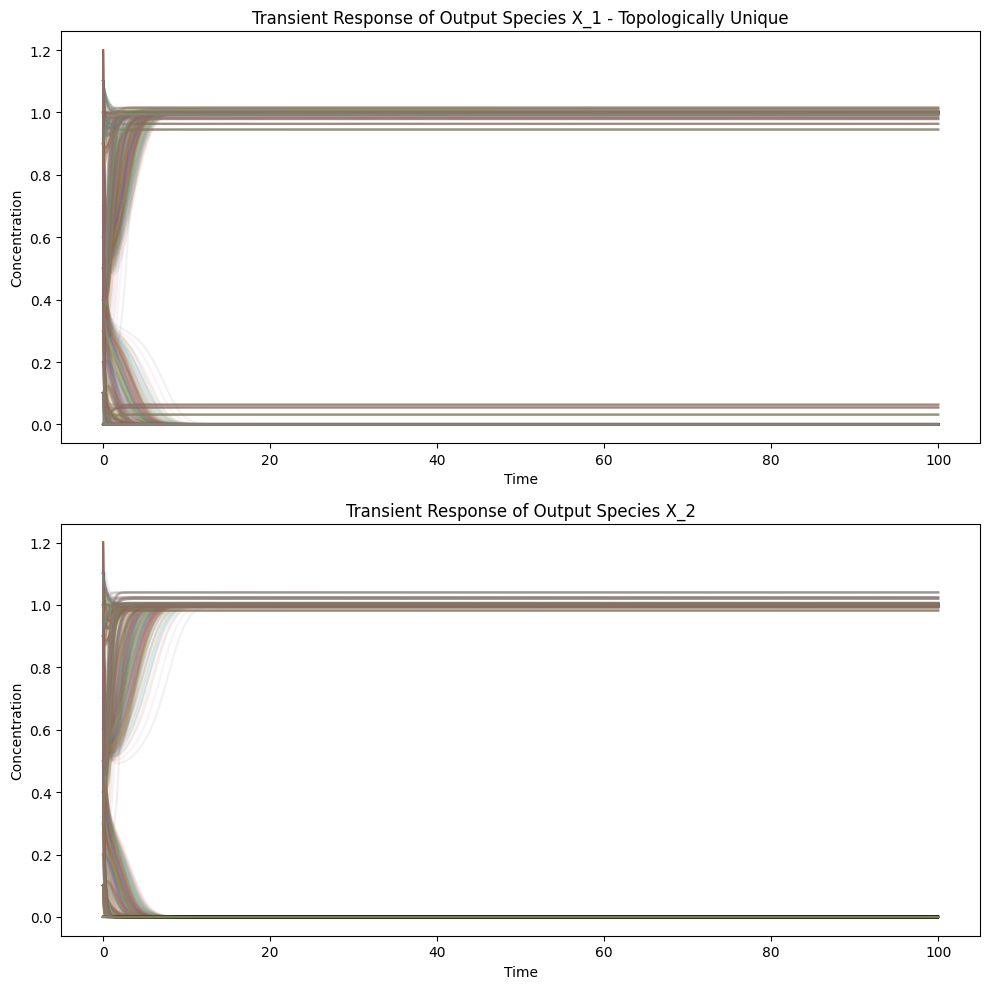

In [7]:
# Plot the responses of the top IOCRNs (topologically not unique)
ax = None
print("sorting...")
all_iocrns_sorted = sorted(all_iocrns, key=lambda iocrn: iocrn.last_task_info['reward'], reverse=False)
print("done ... ")
for i in range(n_unfiltered):
    x0_list = ic.get_ic(all_iocrns_sorted[i])
    fig, ax = all_iocrns_sorted[i].plot_transient_response(axes=ax, alpha=0.1)
ax[0].set_title(ax[0].get_title() + ' - Unfiltered')
print(f'Unfiltered: IOCRN # {0} has a reward of {all_iocrns_sorted[0].last_task_info["reward"]}')
print(f'Unfiltered: IOCRN # {n_unfiltered} has a reward of {all_iocrns_sorted[n_unfiltered-1].last_task_info["reward"]}')

# Plot the responses of the top topologically unique IOCRNs
ax = None
for i in range(n_filtered):
    x0_list = ic.get_ic(all_iocrns_sorted_filtered[i])
    fig, ax = all_iocrns_sorted_filtered[i].plot_transient_response(axes=ax)
ax[0].set_title(ax[0].get_title() + ' - Topologically Unique')
print(f'Filtered: IOCRN # {0} has a reward of {all_iocrns_sorted_filtered[0].last_task_info["reward"]}')
print(f'Filtered: IOCRN # {n_filtered} has a reward of {all_iocrns_sorted_filtered[n_filtered-1].last_task_info["reward"]}')

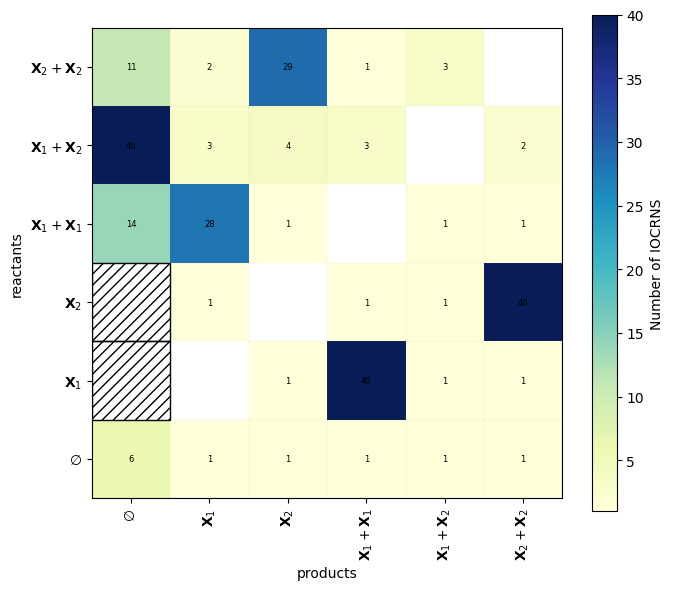

In [8]:
# Plot the reactant-product scatter for the top unfiltered IOCRNs
rewards_sorted = [iocrn.last_task_info['reward'] for iocrn in all_iocrns_sorted]
rewards_sorted_filtered = [iocrn.last_task_info['reward'] for iocrn in all_iocrns_sorted_filtered]

plot_reactant_product_scatter(
    all_iocrns_sorted_filtered[0:n_filtered],
    perf=rewards_sorted_filtered[0:n_filtered],
    species_labels=species_labels,
    max_order= mak_order,
    num_reactions_template=num_reactions_template,
    title="",
    cmap_name="viridis",
    max_ticks=20,
    figsize=(6, 5),
    jitter_scale=0.45,
    use_plotly=True  # ENABLE INTERACTIVE PLOTTING WITH PLOTLY
)

# Plot the reactant-product heatmap for the top filtered IOCRNs (topologically unique)
plot_reactant_product_heatmap(
    all_iocrns_sorted_filtered[0:n_filtered],
    species_labels,
    max_order= mak_order,
    num_reactions_template=num_reactions_template,
    title="",
    cmap_name="YlGnBu",
    max_ticks=20,
    figsize=(7, 6),
)

Applied reward weighting (alpha=10.0). Edges stretched by fitness gaps.
Computing layout (mds)...
Dual Coloring: Face=Loss (Greyscale), Edge=Cluster (Rainbow) with Black Separator


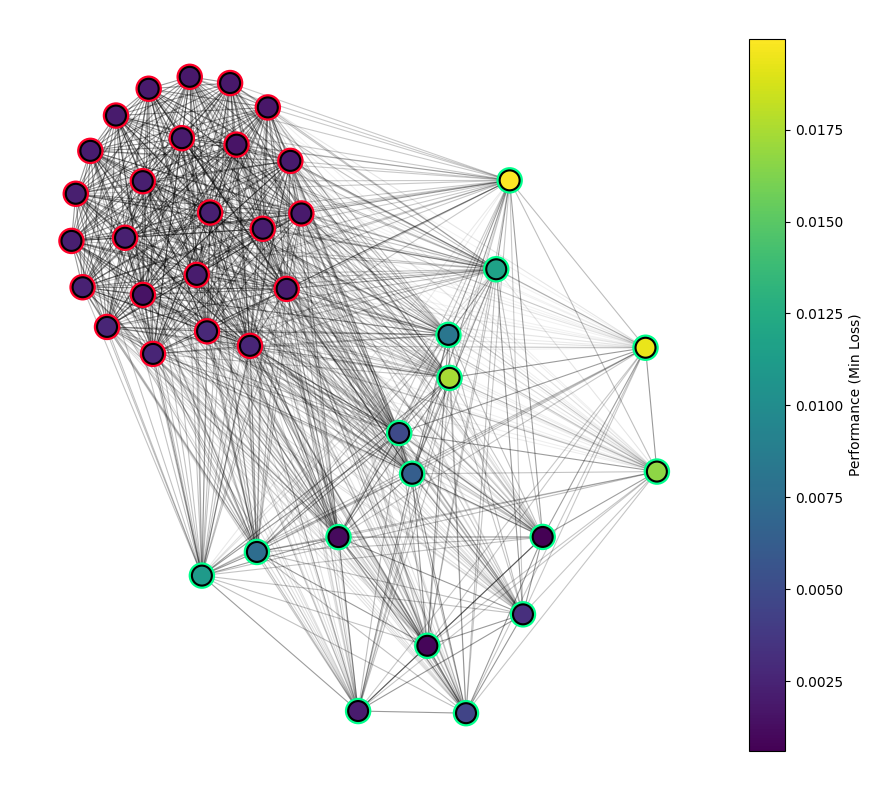

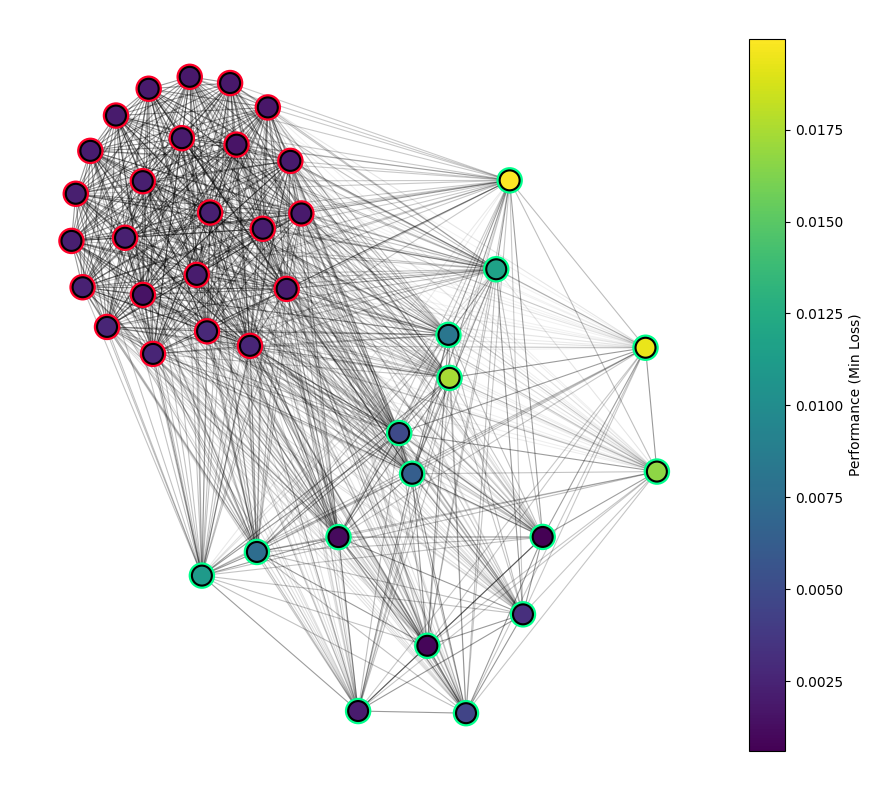

In [9]:
# Visualize the diversity of the top filtered IOCRNs (topologically unique)
visualize_crn_diversity(all_iocrns_sorted_filtered[:n_filtered], perf=rewards_sorted_filtered[:n_filtered], k=None, t=12, layout_method="mds", label_percentile=50, alpha=10.0, unique=True)  # <--- ENABLE REWARD-WEIGHTED TOPOLOGY WITH ALPHA=10.0

In [10]:
# Select three IOCRNs to highlight their responses
iocrn_indices_to_highlight = [0, 10, 13]

# Print the highlighted IOCRNs and their rewards
for idx in iocrn_indices_to_highlight:
    iocrn = all_iocrns_sorted_filtered[idx]
    reward = iocrn.last_task_info['reward']
    print(f'IOCRN {idx} (Loss: {reward}):')
    print(iocrn)
    print('-'*40)

IOCRN 0 (Loss: 0.0005862443980116228):
Inputs: ['u_1'] 
Species: ['X_1', 'X_2'] 
Output Species: ['X_1', 'X_2'] 
∅ ----> ∅;  [MAK(2.1519336700439453)]
X_1 ----> ∅;  [MAK(1.0, u_1)]
X_1 ----> X_1 + X_1;  [MAK(5.101456165313721)]
X_2 ----> ∅;  [MAK(1.0)]
X_2 ----> X_2 + X_2;  [MAK(5.6111836433410645)]
X_1 + X_1 ----> ∅;  [MAK(2.049760341644287)]
X_1 + X_2 ----> ∅;  [MAK(15.792623519897461)]
X_2 + X_2 ----> ∅;  [MAK(2.3048765659332275)]
----------------------------------------
IOCRN 10 (Loss: 0.0019289013428168314):
Inputs: ['u_1'] 
Species: ['X_1', 'X_2'] 
Output Species: ['X_1', 'X_2'] 
∅ ----> ∅;  [MAK(1.5695149898529053)]
X_1 ----> ∅;  [MAK(1.0, u_1)]
X_1 ----> X_1 + X_1;  [MAK(2.5649573802948)]
X_2 ----> ∅;  [MAK(1.0)]
X_2 ----> X_2 + X_2;  [MAK(2.6719722747802734)]
X_1 + X_1 ----> X_1;  [MAK(1.5627602338790894)]
X_1 + X_2 ----> ∅;  [MAK(4.005629539489746)]
X_2 + X_2 ----> X_2;  [MAK(1.6696805953979492)]
----------------------------------------
IOCRN 13 (Loss: 0.0019677320851446997):

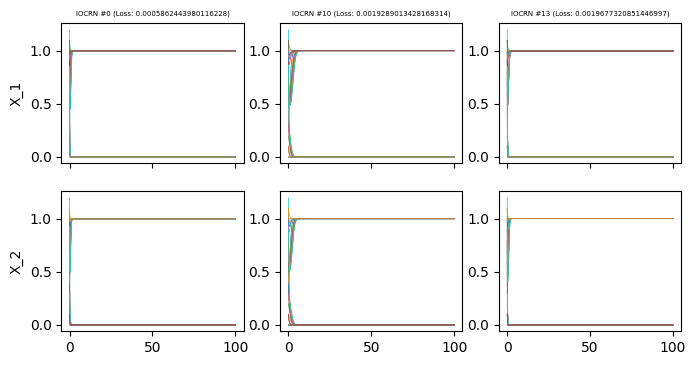

In [11]:
# Plot the responses (all species) of the following selected IOCRNs
fig, ax = plt.subplots(len(species_labels), len(iocrn_indices_to_highlight), figsize=(8, 2*len(species_labels)), sharex=True)

for i in range(len(iocrn_indices_to_highlight)):
    info = all_iocrns_sorted_filtered[iocrn_indices_to_highlight[i]].last_task_info
    t = info["time_horizon"]
    trajectories = info["trajectories"]
    ax[0, i].set_title(f'IOCRN #{iocrn_indices_to_highlight[i]} (Loss: {info["reward"]})', fontsize=5)
    for j in range(len(species_labels)):
        if i == 0:
            ax[j, i].set_ylabel(species_labels[j])
        for k in range(len(trajectories)):
            ax[j, i].plot(t, trajectories[k][j, :], alpha=1, linewidth=0.5)

Filtered: IOCRN # 0 has a reward of 0.0005862443980116228
Filtered: IOCRN # 39 has a reward of 0.019977691739897115


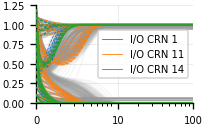

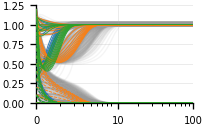

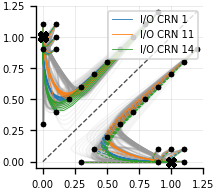

In [44]:
# Transient dynamics plot
plt.rcParams.update({
    "font.size": 6,
    "axes.labelsize": 6,
    "axes.titlesize": 6,
    "legend.fontsize": 6,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.2,
    "figure.dpi": 120,
    "savefig.dpi": 600,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
})

fig1, ax1 = plt.subplots(figsize=(2.5*0.7, 1.85*0.6), constrained_layout=True) 
fig2, ax2 = plt.subplots(figsize=(2.5*0.7, 1.85*0.6), constrained_layout=True) 
fig3, ax3 = plt.subplots(figsize=(1.85, 1.65), constrained_layout=True)

# --------- Plot all traces in light gray (topologically unique) ----------
alpha_bg = 0.1     # transparency for background traces
lw_bg = 0.8         # line width for background traces
time_shift = 1      # shift time to avoid log(0)

for i in range(n_filtered):
    info = all_iocrns_sorted_filtered[i].last_task_info
    t = info["time_horizon"] + time_shift
    outs = info["outputs"]

    for j in range(len(outs)):
        ax1.plot(t, outs[j][0, :], color="0.6", alpha=alpha_bg, linewidth=lw_bg, zorder=1)
        ax2.plot(t, outs[j][1, :], color="0.6", alpha=alpha_bg, linewidth=lw_bg, zorder=1)
        ax3.plot(outs[j][0, :], outs[j][1, :], color="0.6", alpha=alpha_bg, linewidth=lw_bg, zorder=1)

print(f'Filtered: IOCRN # {0} has a reward of {all_iocrns_sorted_filtered[0].last_task_info["reward"]}')
print(f'Filtered: IOCRN # {n_filtered-1} has a reward of {all_iocrns_sorted_filtered[n_filtered-1].last_task_info["reward"]}')

# --------- Highlight the selected IOCRNs ----------
lw_hi = 0.5

for i in range(len(iocrn_indices_to_highlight)):
    info = all_iocrns_sorted_filtered[iocrn_indices_to_highlight[i]].last_task_info
    t = info["time_horizon"] + time_shift
    outs = info["outputs"]

    color = f"C{i}"  # Matplotlib standard cycle
    label = f"I/O CRN {i+1}"

    for j in range(len(outs)):
        if outs[j][0, 0] < outs[j][1, 0]:
            linestyle = "-"
        else: 
            linestyle = "--"

        ax1.plot(
            t, outs[j][0, :],
            alpha=1.0,
            color=color, linewidth=lw_hi, linestyle=linestyle,
            zorder=3,
            label=label if j == 0 else None   # label once per i
        )
        ax2.plot(
            t, outs[j][1, :],
            alpha=1.0,
            color=color, linewidth=lw_hi, linestyle=linestyle,
            zorder=3,
            label=label if j == 0 else None   # label once per i
        )
        ax3.plot(
            outs[j][0, :], outs[j][1, :],
            alpha=1.0,
            color=color, linewidth=lw_hi, linestyle=linestyle,
            zorder=3,
            label=label if j == 0 else None   # label once per i
        )
        ax3.scatter(outs[j][0, 0], outs[j][1, 0], color="0.0", marker="o", s=5, zorder=4)   # initial point
        ax3.scatter(outs[j][0, -1], outs[j][1, -1], color="0.0", marker="X", s=40, zorder=4, linewidths=0.0001)  # final point

# --------- Axes cosmetics ----------
ax1.xaxis.set_major_locator(MaxNLocator(nbins=5))
ax1.yaxis.set_major_locator(MaxNLocator(nbins=5))
ax2.xaxis.set_major_locator(MaxNLocator(nbins=5))
ax2.yaxis.set_major_locator(MaxNLocator(nbins=5))
ax3.xaxis.set_major_locator(MaxNLocator(nbins=5))
ax3.yaxis.set_major_locator(MaxNLocator(nbins=5))

ax1.grid(True, which="major", linewidth=0.6, alpha=0.25)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax2.grid(True, which="major", linewidth=0.6, alpha=0.25)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax3.grid(True, which="major", linewidth=0.6, alpha=0.25)
ax3.spines["top"].set_visible(False)
ax3.spines["right"].set_visible(False)

# --------- Scales/limits (set before setpoint lines so we know xmin/xmax) ----------
ax1.set_xscale("log")
ax1.set_ylim(0, 1.25)
ax1.set_xlim(time_shift, t_f + time_shift)
ax2.set_xscale("log")
ax2.set_ylim(0, 1.25)
ax2.set_xlim(time_shift, t_f + time_shift)
ax3.set_ylim(-0.05, 1.25)
ax3.set_xlim(-0.05, 1.25)     
        
# Legend for colored lines should not have alpha:
color_handles = [Line2D([0], [0], color=f"C{i}", lw=lw_hi, alpha=1.0) for i in range(len(iocrn_indices_to_highlight))]
color_labels  = [f"I/O CRN {i+1}" for i in iocrn_indices_to_highlight]

# Line for separation
ax3.plot([0, 1.2], [0, 1.2], color="0.3", linestyle="--", linewidth=0.8, zorder=2)

handles = color_handles# + [setpoint_handle]
labels  = color_labels #+ ["Setpoint"]

ax1.set_xticks(np.array([0, 10, 100]) + time_shift)
ax1.set_xticklabels(ax1.get_xticks() - time_shift, rotation=0)
ax2.set_xticks(np.array([0, 10, 100]) + time_shift)
ax2.set_xticklabels(ax2.get_xticks() - time_shift, rotation=0)
ax3.set_xticks(np.linspace(0, 1.25, 6))
ax3.set_yticks(np.linspace(0, 1.25, 6))

ax1.legend(handles=handles, labels=labels, frameon=True, loc="best", handlelength=2)
ax3.legend(handles=handles, labels=labels, frameon=True, loc="upper right", handlelength=2)
plt.show()

if save_figures_flag is True:
    fig1.savefig(os.path.join(target_directory, 'plots', "multistability_2species_6rxns_transient_dynamics1.pdf"))
    fig2.savefig(os.path.join(target_directory, 'plots', "multistability_2species_6rxns_transient_dynamics2.pdf"))
    fig3.savefig(os.path.join(target_directory, 'plots', "multistability_2species_6rxns_phase_plane.pdf"))

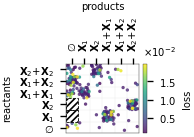

In [13]:
# Reactant-Product Scatter Plot
plot_dic = {
        "font.size": 6,
        "axes.labelsize": 6,
        "axes.titlesize": 6,
        "legend.fontsize": 6,
        "xtick.labelsize": 6,
        "ytick.labelsize": 6,
        "axes.linewidth": 0.2,
        "lines.linewidth": 1.2,
        "figure.dpi": 120,
        "savefig.dpi": 600,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.02,
    }

fig = plot_reactant_product_scatter(
    all_iocrns_sorted_filtered[0:n_filtered],
    perf=rewards_sorted_filtered[0:n_filtered],
    species_labels=species_labels,
    max_order= mak_order,
    num_reactions_template=num_reactions_template,
    title="",
    cmap_name="viridis",
    max_ticks=20,
    figsize=(2*0.85, 1.5*0.85),
    jitter_scale=0.45,
    use_plotly=False,
    plot_dic=plot_dic,
    marker_size=4
)

if save_figures_flag is True:
    fig.savefig(os.path.join(target_directory, 'plots', "multistability_2species_6rxns_reactant_product_scatter.pdf"))

Applied reward weighting (alpha=10.0). Edges stretched by fitness gaps.
Computing layout (mds)...
Dual Coloring: Face=Loss (Greyscale), Edge=Cluster (Rainbow) with Black Separator


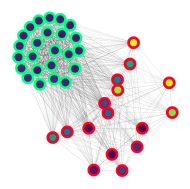

In [14]:
# Topological diversity graph
plot_dic = {
        "font.size": 6,
        "axes.labelsize": 6,
        "axes.titlesize": 6,
        "legend.fontsize": 6,
        "xtick.labelsize": 6,
        "ytick.labelsize": 6,
        "axes.linewidth": 0.8,
        "lines.linewidth": 1.2,
        "figure.dpi": 120,
        "savefig.dpi": 600,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.02,
    }

graph_dic = {
        "fontsize": 3,                  # font size for node labels 
        "edgewidth": 0.1,               # width of the edges in the graph
        "nodesize_multiplier":10,       # multiplier for node sizes
        "nodesize_offset": 0,           # offset for node sizes
        "show_colorbar": False,         # whether to show colorbar for node colors
        "innersize_ratio": 3,           # ratio for inner size of nodes
        "inner_node_linewidth": 0.1,    # width of the inner node borders 
        "outer_node_linewidth": 5.0     # width of the outer node borders
    }

fig = visualize_crn_diversity(
    all_iocrns_sorted_filtered[:n_filtered], 
    perf=rewards_sorted_filtered[:n_filtered], 
    k=None, 
    t=12, 
    layout_method="mds", 
    label_percentile=50, 
    alpha=10.0, 
    unique=True, 
    plot_dic=plot_dic,
    graph_dic=graph_dic,
    figsize=(2, 2)
)

if save_figures_flag is True:
    fig.savefig(os.path.join(target_directory, 'plots', "multistability_2species_6rxns_topology_diversity.pdf"))

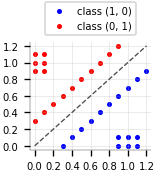

In [15]:
# Visualize the initial conditions colored by their target class
plt.rcParams.update({
    "font.size": 6,
    "axes.labelsize": 6,
    "axes.titlesize": 6,
    "legend.fontsize": 6,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "axes.linewidth": 0.2,
    "lines.linewidth": 1.2,
    "figure.dpi": 120,
    "savefig.dpi": 600,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
})

ic_crn_template = ic_values

fig1, ax1 = plt.subplots(figsize=(1.35, 1.5), constrained_layout=True) 

for i in range(len(ic_crn_template)):
    if (r_list[i] == np.array([1, 0])).all():
        ax1.scatter(ic_crn_template[i][0], ic_crn_template[i][1], s=4,color='blue', label='class (1, 0)' if i==0 else "")
    else:
        ax1.scatter(ic_crn_template[i][0], ic_crn_template[i][1], s=4, color='red', label='class (0, 1)' if i==len(ic_crn_template)//2 else "")

# --------- Axes cosmetics ----------
ax1.xaxis.set_major_locator(MaxNLocator(nbins=5))
ax1.yaxis.set_major_locator(MaxNLocator(nbins=5))

ax1.grid(True, which="major", linewidth=0.6, alpha=0.25)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

# --------- Scales/limits (set before setpoint lines so we know xmin/xmax) ----------
ax1.set_ylim(-0.05, 1.25)
ax1.set_xlim(-0.05, 1.25)

# Line for separation
ax1.plot([0, 1.2], [0, 1.2], color="0.3", linestyle="--", linewidth=0.8, zorder=2)

handles = color_handles# + [setpoint_handle]
labels  = color_labels #+ ["Setpoint"]

ax1.set_xticks(np.array([0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2]))
ax1.set_yticks(np.array([0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2]))

# ax1.legend(frameon=True, loc="best", handlelength=2)
ax1.legend(loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=1, frameon=True)

plt.show()

if save_figures_flag is True:
    fig1.savefig(os.path.join(target_directory, 'plots', "multistability_2species_6rxns_initial_conditions.pdf"))

In [16]:
# Construct a new set of IOCRN initial conditions
ic_max = 2
num_ic = 10
ic_grid = np.linspace(0.01, ic_max, num_ic).tolist()

ic_values_new = []
for x_1 in ic_grid:
    for x_2 in ic_grid:
        if np.abs(x_1 - x_2) > 0.1:
            ic_values_new.append([x_1, x_2])

ic_new = IC(names=species_labels, values=ic_values_new)

# Construct the desired fixed points
r_list_new = []
for ic_value in ic_values_new:
    if ic_value[0] >= ic_value[1]:
        r_list_new.append(np.array([1, 0]))
    else:
        r_list_new.append(np.array([0, 1]))

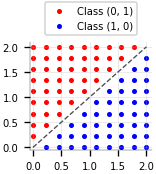

In [30]:
# Visualize the new initial conditions colored by their target class
plt.rcParams.update({
    "font.size": 6,
    "axes.labelsize": 6,
    "axes.titlesize": 6,
    "legend.fontsize": 6,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "axes.linewidth": 0.2,
    "lines.linewidth": 1.2,
    "figure.dpi": 120,
    "savefig.dpi": 600,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
})

ic_crn_template = ic_values_new

fig1, ax1 = plt.subplots(figsize=(1.35, 1.5), constrained_layout=True) 

found_class_1 = False
found_class_2 = False
for i in range(len(ic_values_new)):
    if (r_list_new[i] == np.array([1, 0])).all():
        plt.scatter(ic_values_new[i][0], ic_values_new[i][1], s=4, color='blue', label='Class (1, 0)' if not found_class_1 else "")
        found_class_1 = True
    else:
        plt.scatter(ic_values_new[i][0], ic_values_new[i][1], s=4, color='red', label='Class (0, 1)' if not found_class_2 else "")
        found_class_2 = True

# --------- Axes cosmetics ----------
ax1.xaxis.set_major_locator(MaxNLocator(nbins=5))
ax1.yaxis.set_major_locator(MaxNLocator(nbins=5))

ax1.grid(True, which="major", linewidth=0.6, alpha=0.25)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

# --------- Scales/limits (set before setpoint lines so we know xmin/xmax) ----------
ax1.set_ylim(-0.05, 2.1)
ax1.set_xlim(-0.05, 2.1)

# Line for separation
ax1.plot([0, ic_max], [0, ic_max], color="0.3", linestyle="--", linewidth=0.8, zorder=2)

handles = color_handles# + [setpoint_handle]
labels  = color_labels #+ ["Setpoint"]

# ax1.set_xticks(np.array([0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2]))
# ax1.set_yticks(np.array([0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2]))

# ax1.legend(frameon=True, loc="best", handlelength=2)
ax1.legend(loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=1, frameon=True)

plt.show()

if save_figures_flag is True:
    fig1.savefig(os.path.join(target_directory, 'plots', "multistability_2species_6rxns_initial_conditions.pdf"))

In [18]:
# Resimulate the dynamics of the top filtered IOCRNs with the new initial conditions
parallel_flag = True

# Construct the compute reward routine with the new initial conditions and targets
def compute_reward_new(state):
    x0_list_new = ic_new.get_ic(state)
    return dynamic_tracking_error(state, u_list, x0_list_new, time_horizon, r_list_new, w, norm=1, relative=False, LARGE_NUMBER=1e4)

iocrns_resimulated = []
# Deepcopy and reset all IOCRNs
for iocrn in all_iocrns_sorted_filtered[0:n_filtered]:
    iocrn_copy = iocrn.clone()
    iocrn_copy.reset()
    iocrn_copy.atol = 1e-9
    iocrn_copy.rtol = 1e-9
    iocrns_resimulated.append(iocrn_copy)

# Simulate each IOCRN
if parallel_flag:
    results = Parallel(n_jobs=N_CPUs)(delayed(compute_reward_new)(iocrn) for iocrn in iocrns_resimulated) 
else:
    results = []
    for iocrn in iocrns_resimulated:
        results.append(compute_reward_new(iocrn))

# Unzip the results
rewards_list_new, last_task_info_list_new = zip(*results)
rewards_list_new = list(rewards_list_new)
last_task_info_list_new = list(last_task_info_list_new)

# Update the last task info in each IOCRN since running in parallel does not modify the IOCRNs themselves
for i, iocrn in enumerate(iocrns_resimulated):
    iocrn.last_task_info = last_task_info_list_new[i]   

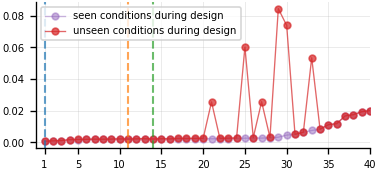

In [ ]:
# Plot the new rewards after resimulation and before
rewards_sorted_resimulated = [iocrn.last_task_info['reward'] for iocrn in iocrns_resimulated]

plt.rcParams.update({
    "font.size": 6,
    "axes.labelsize": 6,
    "axes.titlesize": 6,
    "legend.fontsize": 6,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.2,
    "figure.dpi": 120,
    "savefig.dpi": 600,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
})

fig, ax = plt.subplots(figsize=(4*0.8, 1.85*0.8), constrained_layout=True) 
ax.plot(range(1, n_filtered+1), rewards_sorted_filtered[0:n_filtered], marker='o', color='tab:purple', markersize=4, linestyle='-', linewidth=0.8, alpha=0.5, label='seen conditions during design')
ax.plot(range(1, n_filtered+1), rewards_sorted_resimulated, marker='o', color='tab:red', markersize=4, linestyle='-', linewidth=0.8, alpha=0.7, label='unseen conditions during design')
for idx in iocrn_indices_to_highlight:
    ax.axvline(x=idx+1, color=f"C{iocrn_indices_to_highlight.index(idx)}", linestyle='--', linewidth=lw_hi*2.5, alpha=0.7, zorder=2)
ax.grid(True, which="major", linewidth=0.6, alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xlim(0, n_filtered)
# ax.set_ylim(0, 0.09)
ax.set_xticks([1 if x == 0 else x for x in ax.get_xticks()])
ax.legend(frameon=True, loc="upper left")

plt.show()

if save_figures_flag is True:
    fig.savefig(os.path.join(target_directory, 'plots', "multistability_2species_6rxns_losses_resimulation.pdf"))

Filtered: IOCRN # 0 has a reward of 0.0006398335410196743
Filtered: IOCRN # 39 has a reward of 0.019988592334680137


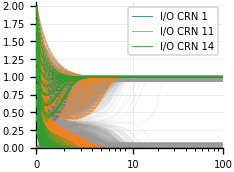

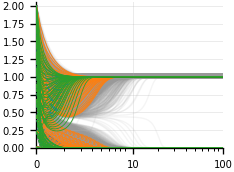

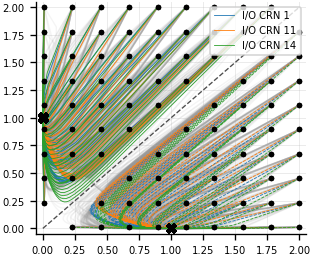

In [42]:
# Transient dynamics plot
plt.rcParams.update({
    "font.size": 6,
    "axes.labelsize": 6,
    "axes.titlesize": 6,
    "legend.fontsize": 6,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.2,
    "figure.dpi": 120,
    "savefig.dpi": 600,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
})

fig1, ax1 = plt.subplots(figsize=(2.5*0.8, 1.85*0.8), constrained_layout=True) 
fig2, ax2 = plt.subplots(figsize=(2.5*0.8, 1.85*0.8), constrained_layout=True) 
fig3, ax3 = plt.subplots(figsize=(2.65, 2.2), constrained_layout=True)

# --------- Plot all traces in light gray (topologically unique) ----------
alpha_bg = 0.1     # transparency for background traces
lw_bg = 0.8         # line width for background traces
time_shift = 1      # shift time to avoid log(0)

for i in range(n_filtered):
    info = iocrns_resimulated[i].last_task_info
    t = info["time_horizon"] + time_shift
    outs = info["outputs"]

    for j in range(len(outs)):
        ax1.plot(t, outs[j][0, :], color="0.6", alpha=alpha_bg, linewidth=lw_bg, zorder=1)
        ax2.plot(t, outs[j][1, :], color="0.6", alpha=alpha_bg, linewidth=lw_bg, zorder=1)
        ax3.plot(outs[j][0, :], outs[j][1, :], color="0.6", alpha=alpha_bg, linewidth=lw_bg, zorder=1)

print(f'Filtered: IOCRN # {0} has a reward of {iocrns_resimulated[0].last_task_info["reward"]}')
print(f'Filtered: IOCRN # {n_filtered-1} has a reward of {iocrns_resimulated[n_filtered-1].last_task_info["reward"]}')

# --------- Highlight the selected IOCRNs ----------
lw_hi = 0.5

for i in range(len(iocrn_indices_to_highlight)):
    info = iocrns_resimulated[iocrn_indices_to_highlight[i]].last_task_info
    t = info["time_horizon"] + time_shift
    outs = info["outputs"]

    color = f"C{i}"  # Matplotlib standard cycle
    label = f"I/O CRN {i+1}"

    for j in range(len(outs)):
        if outs[j][0, 0] < outs[j][1, 0]:
            linestyle = "-"
        else: 
            linestyle = "--"

        ax1.plot(
            t, outs[j][0, :],
            alpha=1.0,
            color=color, linewidth=lw_hi, linestyle=linestyle,
            zorder=3,
            label=label if j == 0 else None   # label once per i
        )
        ax2.plot(
            t, outs[j][1, :],
            alpha=1.0,
            color=color, linewidth=lw_hi, linestyle=linestyle,
            zorder=3,
            label=label if j == 0 else None   # label once per i
        )
        ax3.plot(
            outs[j][0, :], outs[j][1, :],
            alpha=1.0,
            color=color, linewidth=lw_hi, linestyle=linestyle,
            zorder=3,
            label=label if j == 0 else None   # label once per i
        )
        ax3.scatter(outs[j][0, 0], outs[j][1, 0], color="0.0", marker="o", s=5, zorder=4)   # initial point
        ax3.scatter(outs[j][0, -1], outs[j][1, -1], color="0.0", marker="X", s=40, zorder=4, linewidths=0.0001)  # final point

# --------- Axes cosmetics ----------
ax1.xaxis.set_major_locator(MaxNLocator(nbins=5))
ax1.yaxis.set_major_locator(MaxNLocator(nbins=5))
ax2.xaxis.set_major_locator(MaxNLocator(nbins=5))
ax2.yaxis.set_major_locator(MaxNLocator(nbins=5))
ax3.xaxis.set_major_locator(MaxNLocator(nbins=5))
ax3.yaxis.set_major_locator(MaxNLocator(nbins=5))

ax1.grid(True, which="major", linewidth=0.6, alpha=0.25)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax2.grid(True, which="major", linewidth=0.6, alpha=0.25)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax3.grid(True, which="major", linewidth=0.6, alpha=0.25)
ax3.spines["top"].set_visible(False)
ax3.spines["right"].set_visible(False)

# --------- Scales/limits (set before setpoint lines so we know xmin/xmax) ----------
ax1.set_xscale("log")
ax1.set_ylim(0, ic_max+0.05)
ax1.set_xlim(time_shift, t_f + time_shift)
ax2.set_xscale("log")
ax2.set_ylim(0, ic_max+0.05)
ax2.set_xlim(time_shift, t_f + time_shift)
ax3.set_ylim(-0.05, ic_max+0.05)
ax3.set_xlim(-0.05, ic_max+0.05)     
        
# Legend for colored lines should not have alpha:
color_handles = [Line2D([0], [0], color=f"C{i}", lw=lw_hi, alpha=1.0) for i in range(len(iocrn_indices_to_highlight))]
color_labels  = [f"I/O CRN {i+1}" for i in iocrn_indices_to_highlight]

# Line for separation
ax3.plot([0, ic_max], [0, ic_max], color="0.3", linestyle="--", linewidth=0.8, zorder=2)

handles = color_handles# + [setpoint_handle]
labels  = color_labels #+ ["Setpoint"]

ax1.set_xticks(np.array([0, 10, 100]) + time_shift)
ax1.set_xticklabels(ax1.get_xticks() - time_shift, rotation=0)
ax1.set_yticks(np.linspace(0, ic_max, 9))
ax2.set_xticks(np.array([0, 10, 100]) + time_shift)
ax2.set_xticklabels(ax2.get_xticks() - time_shift, rotation=0)
ax2.set_yticks(np.linspace(0, ic_max, 9))
ax3.set_xticks(np.linspace(0, ic_max, 9))
ax3.set_yticks(np.linspace(0, ic_max, 9))

ax1.legend(handles=handles, labels=labels, frameon=True, loc="best", handlelength=2)
ax3.legend(handles=handles, labels=labels, frameon=True, loc="best", handlelength=2)
plt.show()

if save_figures_flag is True:
#     fig1.savefig(os.path.join(target_directory, 'plots', "multistability_2species_6rxns_transient_dynamics1.pdf"))
#     fig2.savefig(os.path.join(target_directory, 'plots', "multistability_2species_6rxns_transient_dynamics2.pdf"))
    fig3.savefig(os.path.join(target_directory, 'plots', "multistability_2species_6rxns_phase_plane_resimulation.pdf"))